In [3]:
import pandas as pd
df = pd.read_csv("../csv/capcut_reviews_cleaned.csv")
df.head()

,reviewId,content,score,at,lang,sentiment,clean_text,cleaned
0,dc2b9c31-bedd-4fae-942d-5c7556ff7840,𝘀𝗮𝗻𝗴𝗮𝘁𝗮𝘂 𝗯𝗮𝗴𝘂𝘀👍😍😊,5,2026-03-09 19:58:55,id,positif,sangatau bagus,sangatau bagus
1,70f70c28-cbf0-4ed4-ad59-64e8a4574342,bagus,5,2026-03-09 19:55:07,id,positif,bagus,bagus
2,3365d762-ff70-4441-87ee-b36fd49677af,"kenapa ya pas buka template, trus di play vide...",3,2026-03-09 19:45:13,id,negatif,kenapa ya pas buka template terus di play vide...,kenapa ya pas buka template terus di play vide...
3,0de67a41-0a28-4803-8316-890cd313a40d,saya mengasih bintang 4 karena apk ini sanagt ...,4,2026-03-09 19:43:43,id,positif,saya mengasih bintang 4 karena aplikasi ini sa...,saya mengasih bintang 4 karena aplikasi ini sa...
4,6d01d7e5-cfd2-42c1-b149-557f9cec3153,di update udah tetep aja kayak apk 8bit eror+l...,1,2026-03-09 19:43:18,id,negatif,di update sudah tetep saja kayak aplikasi 8bit...,di update sudah tetep saja kayak aplikasi 8bit...


In [1]:
!pip install Sastrawi


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Stopwords Bahasa Indonesia ###
Stopwords Bahasa Indonesia didapatkan dari Sastrawi, karena tidak ada stopwrods Bahasa Indonesia yang bisa didapat dari NLTK.

In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
stop_factory = StopWordRemoverFactory()
more_stopword = [
    # umum
    "dan", "yang", "di", "ke", "dari", "untuk", "ini", "itu", "dengan", "pada",
    "adalah", "juga", "karena", "sebagai", "oleh", "atau", "dalam", "sudah",
    "belum", "saya", "aku", "kami", "kita", "kamu", "dia", "mereka",

    # informal / singkatan
    "yg", "dgn", "dr", "dlm", "aja", "kok", "sih", "deh", "dong", "nih",
    "nya", "lah", "pun", "kan", "tuh", "ga", "gak", "nggak", "tidak",

    # kata kerja umum (sering tidak bermakna kuat)
    "ada", "jadi", "buat", "bikin", "bisa", "dapat", "harus", "ingin",
    "mau", "perlu", "coba", "pakai", "gunakan", "dipakai", "digunakan",

    # konteks aplikasi / review
    "aplikasi", "app", "apk", "capcut", "fitur", "fiturnya", "update",
    "versi", "developer", "pengembang", "download", "install",
    "uninstall", "login", "logout",

    # kata sifat umum (kurang informatif)
    "bagus", "jelek", "baik", "buruk", "keren", "mantap",
    "parah", "lumayan", "biasa", "standar",

    # kata umum review
    "banget", "sekali", "cukup", "terlalu", "lebih", "kurang",
    "masih", "lagi", "terus", "malah", "hanya", "cuma",

    # kata noise tambahan
    "ya", "iya", "ok", "oke", "okey", "sip", "wow",
    "hehe", "wkwk", "wk", "lol", "haha"
]
stopwords = stop_factory.get_stop_words() + more_stopword

stopwords

['yang',
 'untuk',
 'pada',
 'ke',
 'para',
 'namun',
 'menurut',
 'antara',
 'dia',
 'dua',
 'ia',
 'seperti',
 'jika',
 'jika',
 'sehingga',
 'kembali',
 'dan',
 'tidak',
 'ini',
 'karena',
 'kepada',
 'oleh',
 'saat',
 'harus',
 'sementara',
 'setelah',
 'belum',
 'kami',
 'sekitar',
 'bagi',
 'serta',
 'di',
 'dari',
 'telah',
 'sebagai',
 'masih',
 'hal',
 'ketika',
 'adalah',
 'itu',
 'dalam',
 'bisa',
 'bahwa',
 'atau',
 'hanya',
 'kita',
 'dengan',
 'akan',
 'juga',
 'ada',
 'mereka',
 'sudah',
 'saya',
 'terhadap',
 'secara',
 'agar',
 'lain',
 'anda',
 'begitu',
 'mengapa',
 'kenapa',
 'yaitu',
 'yakni',
 'daripada',
 'itulah',
 'lagi',
 'maka',
 'tentang',
 'demi',
 'dimana',
 'kemana',
 'pula',
 'sambil',
 'sebelum',
 'sesudah',
 'supaya',
 'guna',
 'kah',
 'pun',
 'sampai',
 'sedangkan',
 'selagi',
 'sementara',
 'tetapi',
 'apakah',
 'kecuali',
 'sebab',
 'selain',
 'seolah',
 'seraya',
 'seterusnya',
 'tanpa',
 'agak',
 'boleh',
 'dapat',
 'dsb',
 'dst',
 'dll',
 'dahulu

In [6]:
def preprocess_tokens(text):
    if not isinstance(text, str):
        return []
    
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords]
    return tokens

df["tokens"] = df["clean_text"].apply(preprocess_tokens)

df[["clean_text", "tokens"]].head(10)

,clean_text,tokens
0,sangatau bagus,"[sangatau, bagus]"
1,bagus,[bagus]
2,kenapa ya pas buka template terus di play vide...,"[pas, buka, template, terus, play, videonya, g..."
3,saya mengasih bintang 4 karena aplikasi ini sa...,"[mengasih, bintang, 4, aplikasi, sanagt, bagus..."
4,di update sudah tetep saja kayak aplikasi 8bit...,"[update, tetep, kayak, aplikasi, 8bit, erorlem..."
5,bagus,[bagus]
6,aplikasi pembohong katanya langganan 7 hari cm...,"[aplikasi, pembohong, katanya, langganan, 7, h..."
7,bagusss bangett,"[bagusss, bangett]"
8,karena kerennnnnnnnnn,[kerennnnnnnnnn]
9,bagus sih cuma greget saja sama iklan terus ka...,"[bagus, sih, cuma, greget, sama, iklan, terus,..."


,Kata,Frekuensi
0,bagus,1397
1,nya,964
2,aplikasi,835
3,capcut,639
4,sangat,557
...,...,...
95,buka,71
96,masa,71
97,kan,71
98,ni,68


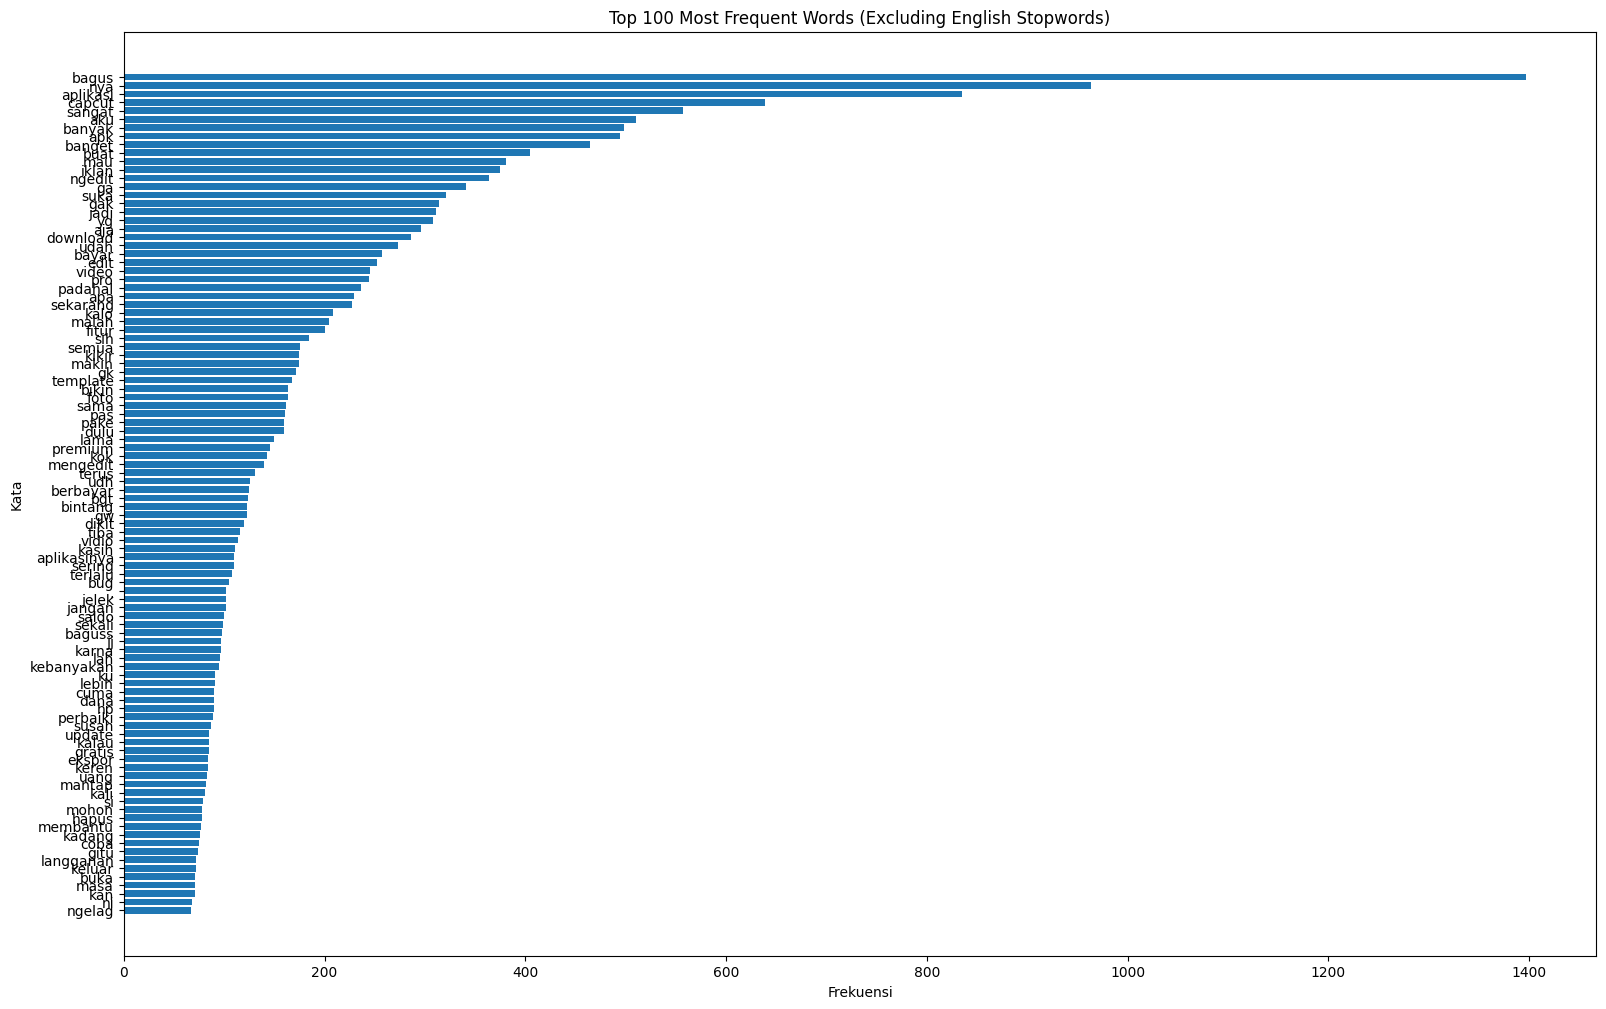

In [ ]:
# Assuming the text column is named 'content'
from typing import Counter
import pandas as pd
import nltk
from collections import Counter
import matplotlib.pyplot as plt

stop_factory = StopWordRemoverFactory()
more_stopword = ['dengan', 'ia', 'bahwa', 'oleh']
stopwords = stop_factory.get_stop_words() + more_stopword

text_column = 'content'

# Combine all text data into one string
all_text = ' '.join(df[text_column].dropna().astype(str))

# Tokenize words and remove stopwords
words = all_text.split()
filtered_words = [word.lower() for word in words if word.lower() not in stopwords]

# Count frequent words
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(100)

# Convert to DataFrame for better visualization
word_freq_df = pd.DataFrame(common_words, columns=['Kata', 'Frekuensi'])

# Display the most common words
display(word_freq_df)

# Plot the frequent words
plt.figure(figsize=(19, 12))
plt.barh(word_freq_df['Kata'][::-1], word_freq_df['Frekuensi'][::-1])
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.title("Top 100 Kata Paling Sering Muncul")
plt.show()

In [10]:
common_words

[('bagus', 1397),
 ('nya', 964),
 ('aplikasi', 835),
 ('capcut', 639),
 ('sangat', 557),
 ('aku', 510),
 ('banyak', 498),
 ('apk', 494),
 ('banget', 464),
 ('buat', 405),
 ('mau', 381),
 ('iklan', 375),
 ('ngedit', 364),
 ('ga', 341),
 ('suka', 321),
 ('gak', 314),
 ('jadi', 311),
 ('yg', 308),
 ('aja', 296),
 ('download', 286),
 ('udah', 273),
 ('bayar', 257),
 ('edit', 252),
 ('video', 245),
 ('pro', 244),
 ('padahal', 236),
 ('apa', 229),
 ('sekarang', 227),
 ('kalo', 208),
 ('malah', 204),
 ('fitur', 200),
 ('sih', 185),
 ('semua', 176),
 ('kikir', 175),
 ('makin', 175),
 ('gk', 172),
 ('template', 168),
 ('bikin', 164),
 ('foto', 164),
 ('sama', 162),
 ('pas', 161),
 ('pake', 160),
 ('dulu', 160),
 ('lama', 150),
 ('premium', 146),
 ('kok', 143),
 ('mengedit', 140),
 ('terus', 131),
 ('udh', 126),
 ('berbayar', 125),
 ('bgt', 124),
 ('bintang', 123),
 ('gw', 123),
 ('dikit', 120),
 ('tiba', 116),
 ('vidio', 114),
 ('kasih', 111),
 ('aplikasinya', 110),
 ('sering', 110),
 ('terlalu

[('bagus', 1397), ('nya', 964), ('aplikasi', 835), ('capcut', 639), ('sangat', 557), ('aku', 510), ('banyak', 498), ('apk', 494), ('banget', 464), ('buat', 405), ('mau', 381), ('iklan', 375), ('ngedit', 364), ('ga', 341), ('suka', 321), ('gak', 314), ('jadi', 311), ('yg', 308), ('aja', 296), ('download', 286), ('udah', 273), ('bayar', 257), ('edit', 252), ('video', 245), ('pro', 244), ('padahal', 236), ('apa', 229), ('sekarang', 227), ('kalo', 208), ('malah', 204), ('fitur', 200), ('sih', 185), ('semua', 176), ('kikir', 175), ('makin', 175), ('gk', 172), ('template', 168), ('bikin', 164), ('foto', 164), ('sama', 162), ('pas', 161), ('pake', 160), ('dulu', 160), ('lama', 150), ('premium', 146), ('kok', 143), ('mengedit', 140), ('terus', 131), ('udh', 126), ('berbayar', 125), ('bgt', 124), ('bintang', 123), ('gw', 123), ('dikit', 120), ('tiba', 116), ('vidio', 114), ('kasih', 111), ('aplikasinya', 110), ('sering', 110), ('terlalu', 108), ('bug', 105), (',', 102), ('jelek', 102), ('jangan

,Kata,Frekuensi
0,bagus,1397
1,nya,964
2,aplikasi,835
3,capcut,639
4,sangat,557
...,...,...
95,buka,71
96,masa,71
97,kan,71
98,ni,68


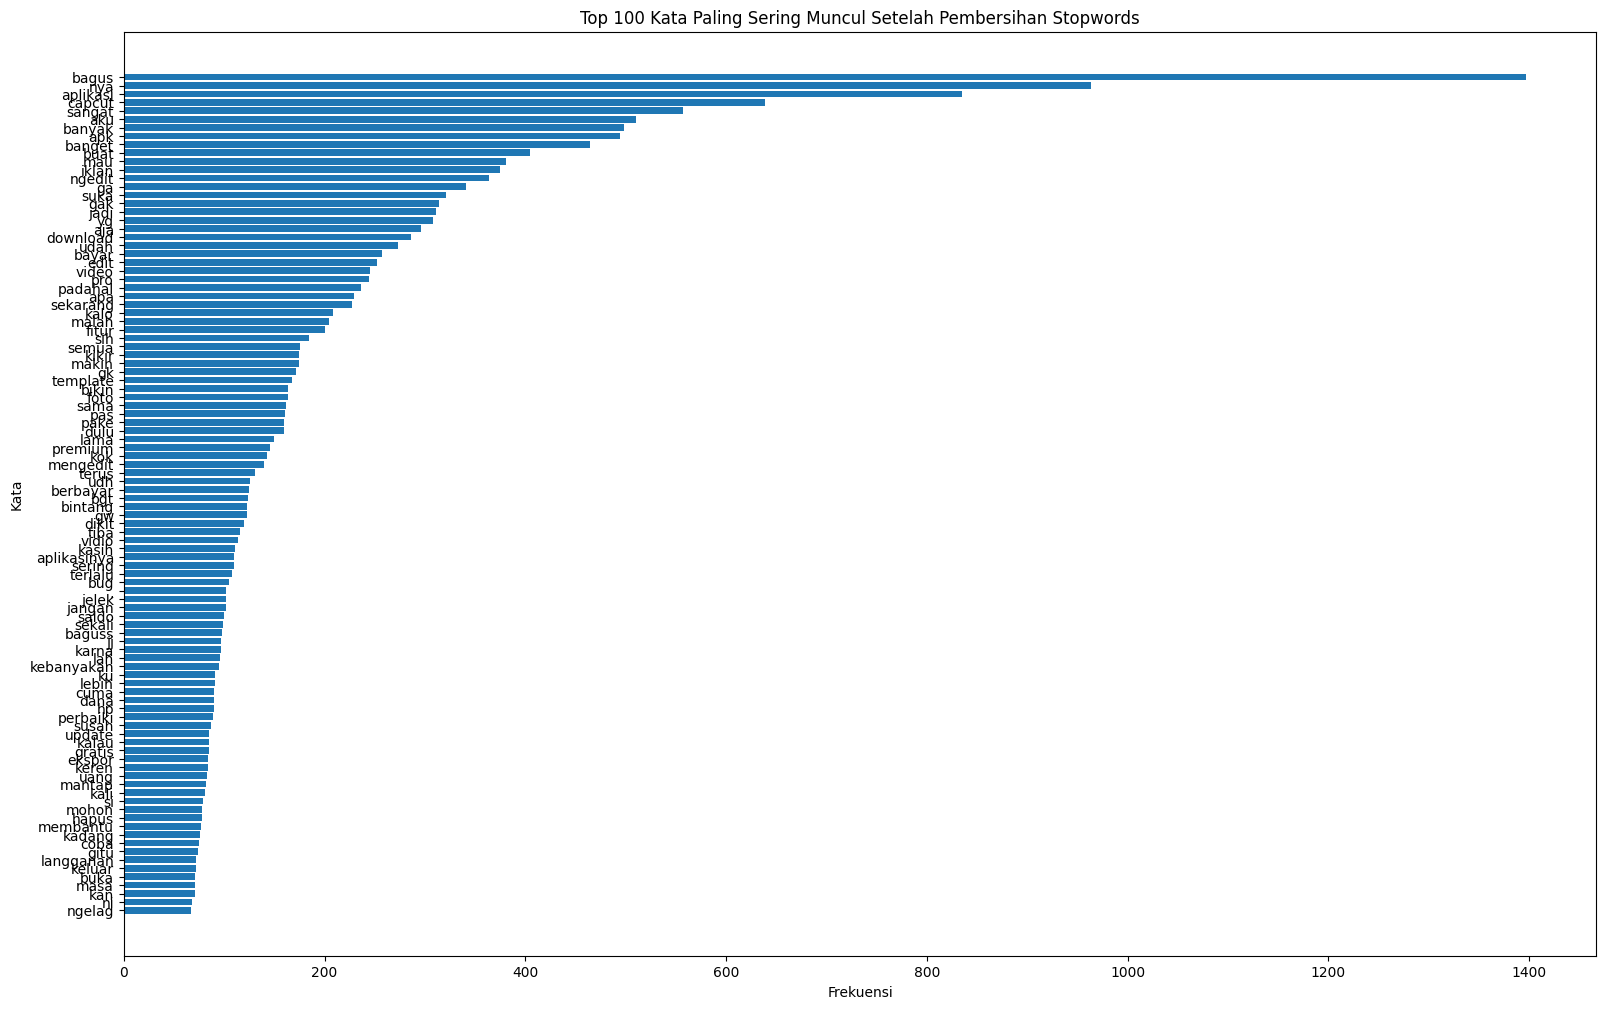

In [11]:

import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Kolom teks
text_column = 'content'

# Gabungkan semua teks
all_text = ' '.join(df[text_column].dropna().astype(str))

# Tokenisasi
words = all_text.split()

# Hapus stopwords (termasuk custom yang sudah kamu tambahkan)
filtered_words = [word.lower() for word in words if word.lower() not in stopwords]

# Hitung frekuensi kata lagi
word_counts = Counter(filtered_words)

# Ambil 100 kata paling sering setelah stopwords baru
common_words_clean = word_counts.most_common(100)

# Convert ke DataFrame
word_freq_df_clean = pd.DataFrame(common_words_clean, columns=['Kata', 'Frekuensi'])

# Print hasil
print(common_words_clean)

# Tampilkan tabel
display(word_freq_df_clean)

# Plot grafik
plt.figure(figsize=(19,12))
plt.barh(word_freq_df_clean['Kata'][::-1], word_freq_df_clean['Frekuensi'][::-1])
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.title("Top 100 Kata Paling Sering Muncul Setelah Pembersihan Stopwords")
plt.show()